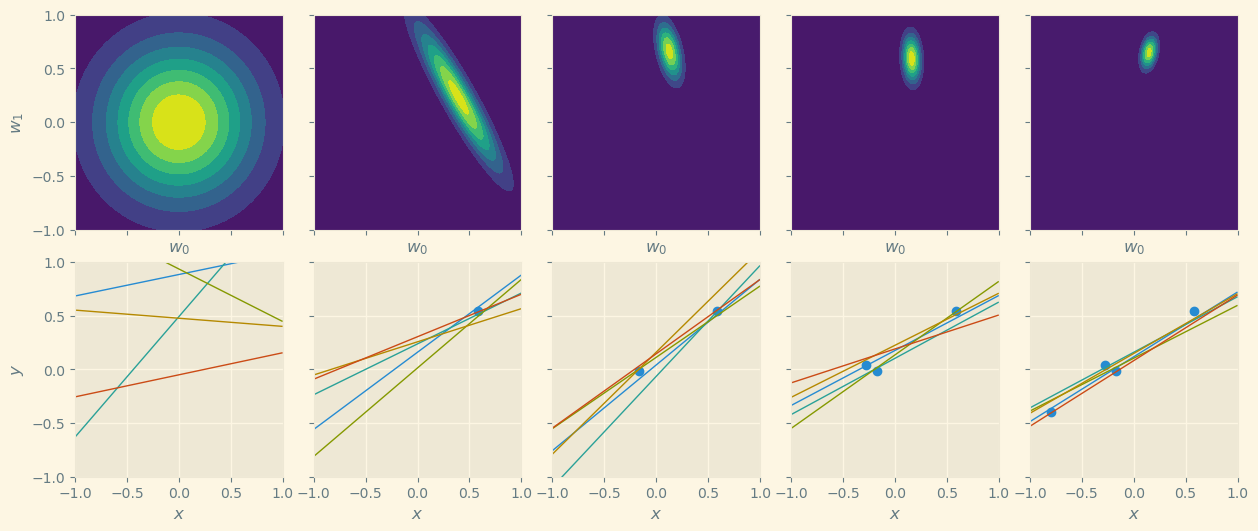

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import scipy.stats as st

np.random.seed(0)
w0_true, w1_true = 0, 0.5
a, b = 4, 100  # 超参数
mu, sigma = np.zeros(2), np.eye(2) / a  # w的先验高斯分布的均值、协方差
n_samples = 4
x, y = [], []
Xy = np.zeros((2, 1))  # sum_i x_i y_i
x_plot = np.arange(-1, 1.01, 0.01)
xx, yy = np.meshgrid(x_plot, x_plot)
pos = np.dstack((np.meshgrid(x_plot, x_plot)))
lines = 5

with plt.style.context('Solarize_Light2'):
    fig, ax = plt.subplots(2, n_samples + 1, sharex=True, sharey=True, figsize=(15, 6))
    plt.subplots_adjust(wspace=0.15, hspace=0.15)
    plt.setp(ax, xlim=(-1, 1), ylim=(-1, 1))

    rv = st.multivariate_normal(mean=mu, cov=sigma)
    ax[0, 0].contourf(xx, yy, rv.pdf(pos))
    ax[0, 0].set_xlabel(r'$w_0$')
    ax[0, 0].set_ylabel(r'$w_1$')

    W = rv.rvs(size=lines)
    for j in range(lines):
        ax[1, 0].plot(x_plot, W[j, 0] + W[j, 1] * x_plot, lw=1)
    ax[1, 0].set_xlabel(r'$x$')
    ax[1, 0].set_ylabel(r'$y$')

    for i in range(n_samples):
        xi = st.uniform.rvs(loc=-1, scale=2)  # [-1,1]上均匀采样
        yi = w0_true + w1_true * xi + st.norm.rvs(loc=0, scale=np.sqrt(1 / b))
        x.append(xi)
        y.append(yi)
        xi = np.array([1, xi]).reshape(2, 1)
        Xy += xi * yi
        sigma = sigma - b * sigma @ xi @ xi.T @ sigma / (1 + b * xi.T @ sigma @ xi)  # Sherman-Morrison 公式
        mu = b * (sigma @ Xy).ravel()
        rv = st.multivariate_normal(mean=mu, cov=sigma)
        ax[0, i + 1].contourf(xx, yy, rv.pdf(pos))
        ax[0, i + 1].set_xlabel(r'$w_0$')

        W = rv.rvs(size=lines)
        for j in range(lines):
            ax[1, i + 1].plot(x_plot, W[j, 0] + W[j, 1] * x_plot, lw=1)
        ax[1, i + 1].scatter(x, y)
        ax[1, i + 1].set_xlabel(r'$x$')

    fig.savefig("plot-prior-post.svg")
    plt.show()